# 一着確率・複勝(3着以内)確率のキャリブレーション評価

## 目的
モデルが出す「一着になる確率」が実測の一着率とどれだけ一致しているか（キャリブレーション）、
および同じ単勝確率から Harville (1973) 近似で導いた「3着以内に入る確率」が実測の複勝率と
どれだけ一致しているかを評価する。

## データと粒度
- 入力: `artifacts/oof_predictions.parquet`（**実データ**、`nar learn` の walk-forward out-of-fold 予測）
- 1行 = 1レースの1頭（`race_id` × `horse_no` が主キー）
- 対象期間: walk-forward の5-fold分（2019-02 〜 2023-12）。トラックA（オッズ非使用）。

## 使うデータについての制約（先に明記する）
実運用で配布したモデルの最終評価は `nar evaluate-final --unlock-oos`（ロック区間 2024-02〜現在）で
行っているが、このコマンドは集計指標（`artifacts/oos_metrics.json`）のみを書き出し、
行単位の予測を永続化しない実装になっている。そのためロック区間のリライアビリティ図は
現状の成果物からは描けない。本ノートブックは代わりに **walk-forward の OOF**（学習に使っていない
検証区間だが、ロック区間ではない）を使う。OOF は各foldの学習に使われていない行のみで構成される
ため、リークはない。ロック区間そのものでのキャリブレーションを見るには、`evaluate-final` が
行単位の予測を書き出すよう実装を拡張する必要がある（docs の運用手順書に申し送り事項として記載）。

## 手法
- 一着確率のキャリブレーション: 等頻度10分位ビンで予測平均と実測一着率を比較（`nar.eval.calibration.reliability_curve` と同じ考え方）。
  ビンごとに Wilson 95%信頼区間（二項比率）を付け、予測平均と実測率の一致を二項検定で確認する。
- 複勝(3着以内)確率: 単勝確率しかモデルは出さないため、`nar.eval.metrics.harville_place_probability`
  （このリポジトリの既存実装）で単勝確率から複勝確率を近似する。Harville の仮定は
  「上位が確定するたびに、残った馬の間では単勝確率を再正規化したものが条件付き確率になる」という
  単純化で、着差分布などの追加情報は使わない。計算量が O(頭数³) のため、計算対象は
  個別最良モデル（LightGBM）とアンサンブルの2つに絞る（全モデルに広げると1モデルあたり
  実測 約85秒 × 5 モデルで計算時間が支配的になり、結論に必要な比較には過剰）。
- 複数の検定（モデル×ビン）を同時に見るため、p値は Benjamini–Hochberg 法（このリポジトリの
  `nar.eval.metrics.benjamini_hochberg`）で補正する（`~/.claude/CLAUDE.md` の多重比較補正の下限）。


In [1]:
import sys, time
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint

from nar.eval.metrics import (
    harville_place_probability, expected_calibration_error, normalize_within_race,
    benjamini_hochberg, race_nll, block_bootstrap_ci,
)

pd.set_option("display.width", 120)
ARTIFACTS = "../artifacts"

plt.rcParams["font.family"] = "Noto Sans CJK JP"   # 日本語ラベルの文字化け防止


## 1. データ読み込みと健全性チェック
粒度（1行=1頭1レース）、重複キー、欠損、fold ごとの件数と期間をまず確認する。
これを飛ばすと後段の集計が何を数えているのか分からなくなる。


In [2]:
df = pd.read_parquet(f"{ARTIFACTS}/oof_predictions.parquet")
print("shape:", df.shape)

dup = df.duplicated(subset=["race_id", "horse_no"]).sum()
print("重複キー(race_id, horse_no):", dup)

na = df.isna().mean().sort_values(ascending=False)
print("\n列ごとの欠損率:")
print(na)

print("\nfold ごとの件数と期間:")
print(df.groupby("fold").agg(n=("race_id", "size"),
                              n_races=("race_id", "nunique"),
                              start=("race_date", "min"),
                              end=("race_date", "max")))


shape: (618685, 11)
重複キー(race_id, horse_no): 0

列ごとの欠損率:
race_id             0.0
horse_no            0.0
race_date           0.0
is_win              0.0
finish_pos          0.0
clogit              0.0
lgbm                0.0
tabm                0.0
bayes               0.0
baseline_uniform    0.0
fold                0.0
dtype: float64

fold ごとの件数と期間:
           n  n_races      start        end
fold                                       
1     123013    12166 2019-02-01 2019-12-31
2     123834    12254 2020-02-01 2020-12-31
3     120417    11870 2021-02-01 2021-12-31
4     124477    12526 2022-02-01 2022-12-31
5     126944    12697 2023-02-01 2023-12-31


欠損・重複キーがゼロであることを確認できたら先に進む（あれば原因を特定するまで集計しない）。


In [3]:
MODEL_COLS = ["clogit", "lgbm", "tabm", "bayes"]

weights = pd.read_csv(f"{ARTIFACTS}/ensemble_weights.csv").set_index("model")["weight"]
print("アンサンブル重み（OOFのみから推定、artifacts/ensemble_weights.csv）:")
print(weights)

w = weights.reindex(MODEL_COLS).to_numpy()
log_p = np.log(np.clip(df[MODEL_COLS].to_numpy(dtype=float), 1e-12, 1.0))
df["ensemble"] = normalize_within_race(np.exp(log_p @ w), df["race_id"].to_numpy())

df["top3_flag"] = (df["finish_pos"] <= 3).astype(int)

ALL_MODELS = MODEL_COLS + ["baseline_uniform", "ensemble"]
race_ids = df["race_id"].to_numpy()


アンサンブル重み（OOFのみから推定、artifacts/ensemble_weights.csv）:
model
clogit    9.610305e-18
lgbm      8.600145e-01
tabm      1.399855e-01
bayes     0.000000e+00
Name: weight, dtype: float64


## 2. 全体サマリー（一着的中・NLL・Brier・ECE）
`nar.eval.metrics.summary` は `ndcg@3` / `spearman` まで計算するが、この2指標は
pandas の `groupby().apply()`（グループごとに Python 関数を呼ぶ実装）を使っており、
61,513 レース × 6 モデル分だと実測で15分のタイムアウトに達した。この2指標は本ノートブックの
目的（キャリブレーション）には不要なので、`race_nll` / `ece` は既存実装をそのまま再利用し、
`brier` / `top1` / `top3` だけベクトル化した groupby 集約（`rank` / `sum` など、pandas が
C実装で処理する集約）で計算し直して速度を確保する。値の定義は `nar.eval.metrics` と同一
（`top_k_accuracy` の k=3 は「予測上位3頭のうち実際に3着以内に入った頭数 ÷ 3」をレース平均）。


In [4]:
def fast_summary(p, y, finish_pos, race_id):
    d = pd.DataFrame({"p": p, "y": y, "pos": finish_pos, "r": race_id})
    n_races = d["r"].nunique()

    rank_desc = d.groupby("r", sort=False)["p"].rank(ascending=False, method="first")
    picked1, picked3 = rank_desc == 1, rank_desc <= 3
    actual1, actual3 = d["pos"] == 1, d["pos"] <= 3
    top1 = float((picked1 & actual1).sum() / n_races)
    top3 = float((picked3 & actual3).sum() / (3 * n_races))

    sq = (d["p"] - d["y"]) ** 2
    brier = float(sq.groupby(d["r"], sort=False).sum().mean())

    return {
        "race_nll": race_nll(p, y, race_id),
        "brier": brier,
        "top1": top1,
        "top3": top3,
        "ece": expected_calibration_error(p, y),
    }

rows = []
for m in ALL_MODELS:
    s = fast_summary(df[m].to_numpy(), df["is_win"].to_numpy(), df["finish_pos"].to_numpy(), race_ids)
    s["model"] = m
    rows.append(s)
summary_df = pd.DataFrame(rows).set_index("model")[
    ["race_nll", "brier", "top1", "top3", "ece"]
].sort_values("race_nll")
summary_df.round(4)


,race_nll,brier,top1,top3,ece
model,,,,,
ensemble,1.8046,0.7714,0.3599,0.5463,0.0031
lgbm,1.8052,0.7715,0.3599,0.5465,0.0033
tabm,1.8249,0.7773,0.3528,0.5391,0.0019
clogit,1.8684,0.7898,0.3388,0.5309,0.0042
baseline_uniform,2.2874,0.8961,0.0948,0.3029,0.0000
bayes,2.3043,0.8997,0.1116,0.3217,0.0102


## 3. 一着確率のキャリブレーション
等頻度10分位ビンで「予測平均」と「実測一着率」を比較する。ビンごとに Wilson 95%信頼区間を出し、
予測平均が実測率の信頼区間内に収まっているかを二項検定で確認する。p値は後段でモデル横断・
複勝側の検定とまとめて BH 補正する。


In [5]:
def reliability_table(p, y, n_bins=10):
    p = np.asarray(p, dtype=float)
    y = np.asarray(y, dtype=float)
    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    idx = np.digitize(p, edges[1:-1], right=True)
    rows = []
    for b in range(n_bins):
        m = idx == b
        if not m.any():
            continue
        n, k = int(m.sum()), int(y[m].sum())
        lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
        pred_mean = float(p[m].mean())
        pval = binomtest(k, n, pred_mean).pvalue
        rows.append(dict(bin=b, n=n, pred_mean=pred_mean, actual_rate=k / n,
                          ci_lo=lo, ci_hi=hi, pval=pval))
    return pd.DataFrame(rows)

win_tables = {}
pending_pvals = []   # (tag, table_index) を後で BH 補正するために集める
for m in ALL_MODELS:
    t = reliability_table(df[m].to_numpy(), df["is_win"].to_numpy())
    t.insert(0, "model", m)
    t.insert(0, "target", "win")
    win_tables[m] = t

win_all = pd.concat(win_tables.values(), ignore_index=True)
win_all.round(4)


,target,model,bin,n,pred_mean,actual_rate,ci_lo,ci_hi,pval
0,win,clogit,0,61869,0.0102,0.0093,0.0086,0.0101,0.0215
1,win,clogit,1,61868,0.0215,0.0184,0.0173,0.0195,0.0000
2,win,clogit,2,61869,0.0316,0.0298,0.0285,0.0312,0.0107
3,win,clogit,3,61868,0.0427,0.0391,0.0376,0.0407,0.0000
4,win,clogit,4,61869,0.0557,0.0540,0.0522,0.0558,0.0608
5,win,clogit,5,61868,0.0720,0.0735,0.0714,0.0755,0.1592
6,win,clogit,6,61868,0.0937,0.0982,0.0959,0.1006,0.0001
7,win,clogit,7,61869,0.1252,0.1313,0.1287,0.1340,0.0000
8,win,clogit,8,61868,0.1804,0.1891,0.1860,0.1922,0.0000
9,win,clogit,9,61869,0.3613,0.3516,0.3479,0.3554,0.0000


### リライアビリティ図（一着確率）
対角線が完全較正。点が対角線から系統的にずれていれば、その確率帯で過大/過小評価している。


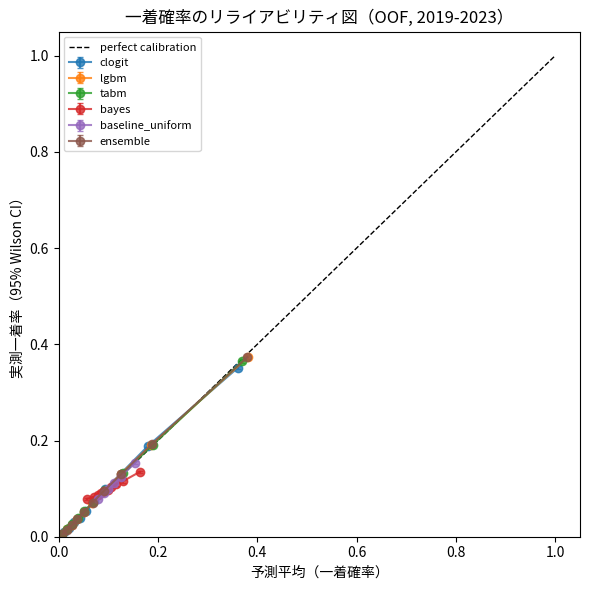

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
for m in ALL_MODELS:
    t = win_tables[m]
    ax.errorbar(t["pred_mean"], t["actual_rate"],
                yerr=[t["actual_rate"] - t["ci_lo"], t["ci_hi"] - t["actual_rate"]],
                marker="o", capsize=2, label=m, alpha=0.8)
ax.set_xlabel("予測平均（一着確率）")
ax.set_ylabel("実測一着率（95% Wilson CI）")
ax.set_title("一着確率のリライアビリティ図（OOF, 2019-2023）")
ax.legend(fontsize=8)
ax.set_xlim(0, None); ax.set_ylim(0, None)
fig.tight_layout()
fig.savefig("win_reliability.png", dpi=120)
plt.show()


## 4. 複勝（3着以内）確率のキャリブレーション
単勝確率から Harville 近似で導いた複勝確率を、実測の3着以内率と比較する。
計算コストの都合で **LightGBM（個別最良）とアンサンブル** の2つに絞る。


In [7]:
HARVILLE_MODELS = ["lgbm", "ensemble"]
place_tables = {}
t0 = time.time()
for m in HARVILLE_MODELS:
    p3 = harville_place_probability(df[m].to_numpy(), race_ids, k=3)
    df[f"{m}_top3_pred"] = p3
    t = reliability_table(p3, df["top3_flag"].to_numpy())
    t.insert(0, "model", m)
    t.insert(0, "target", "top3")
    place_tables[m] = t
    print(f"{m}: Harville 計算 {time.time() - t0:.1f}s 経過")

place_all = pd.concat(place_tables.values(), ignore_index=True)
place_all.round(4)


lgbm: Harville 計算 129.6s 経過


ensemble: Harville 計算 243.7s 経過


,target,model,bin,n,pred_mean,actual_rate,ci_lo,ci_hi,pval
0,top3,lgbm,0,61869,0.0363,0.0387,0.0373,0.0403,0.0012
1,top3,lgbm,1,61868,0.0759,0.0937,0.0915,0.0961,0.0000
2,top3,lgbm,2,61869,0.1131,0.1378,0.1351,0.1406,0.0000
3,top3,lgbm,3,61868,0.1538,0.1840,0.1810,0.1871,0.0000
4,top3,lgbm,4,61869,0.2011,0.2341,0.2307,0.2374,0.0000
5,top3,lgbm,5,61868,0.2583,0.2848,0.2813,0.2884,0.0000
6,top3,lgbm,6,61868,0.3305,0.3465,0.3428,0.3503,0.0000
7,top3,lgbm,7,61869,0.4271,0.4238,0.4199,0.4277,0.1041
8,top3,lgbm,8,61868,0.5694,0.5259,0.5220,0.5299,0.0000
9,top3,lgbm,9,61869,0.8174,0.7152,0.7117,0.7188,0.0000


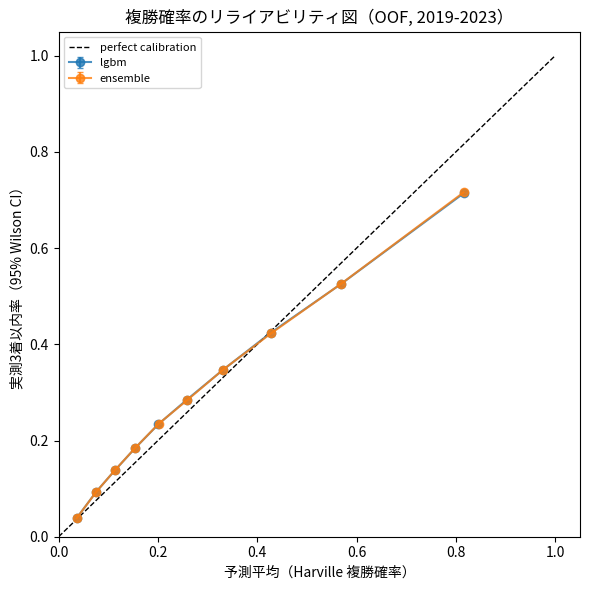

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
for m in HARVILLE_MODELS:
    t = place_tables[m]
    ax.errorbar(t["pred_mean"], t["actual_rate"],
                yerr=[t["actual_rate"] - t["ci_lo"], t["ci_hi"] - t["actual_rate"]],
                marker="o", capsize=2, label=m, alpha=0.8)
ax.set_xlabel("予測平均（Harville 複勝確率）")
ax.set_ylabel("実測3着以内率（95% Wilson CI）")
ax.set_title("複勝確率のリライアビリティ図（OOF, 2019-2023）")
ax.legend(fontsize=8)
ax.set_xlim(0, None); ax.set_ylim(0, None)
fig.tight_layout()
fig.savefig("top3_reliability.png", dpi=120)
plt.show()


## 5. 多重比較補正
一着確率5モデル×10ビン、複勝確率2モデル×10ビンで合計70件の二項検定を行っている。
個々の p値をそのまま5%で判定すると偽陽性が積み上がるので、Benjamini–Hochberg 法で
まとめて補正する（`~/.claude/CLAUDE.md` の多重比較補正の下限）。


In [9]:
combined = pd.concat([win_all, place_all], ignore_index=True)
combined["padj_bh"] = benjamini_hochberg(combined["pval"].to_numpy())
combined["miscalibrated_fdr5pct"] = combined["padj_bh"] < 0.05

print(f"検定件数: {len(combined)}")
print(f"補正前 p<0.05: {(combined['pval'] < 0.05).sum()} 件")
print(f"BH補正後 padj<0.05: {combined['miscalibrated_fdr5pct'].sum()} 件")

cols = ["target", "model", "bin", "n", "pred_mean", "actual_rate", "pval", "padj_bh"]
combined[combined["miscalibrated_fdr5pct"]][cols].sort_values(["target", "model", "bin"]).round(4)


検定件数: 76
補正前 p<0.05: 54 件
BH補正後 padj<0.05: 54 件


,target,model,bin,n,pred_mean,actual_rate,pval,padj_bh
66,top3,ensemble,0,61869,0.0364,0.0386,0.0030,0.0052
67,top3,ensemble,1,61868,0.0760,0.0936,0.0000,0.0000
68,top3,ensemble,2,61869,0.1132,0.1381,0.0000,0.0000
69,top3,ensemble,3,61868,0.1540,0.1844,0.0000,0.0000
70,top3,ensemble,4,61869,0.2014,0.2348,0.0000,0.0000
71,top3,ensemble,5,61868,0.2588,0.2839,0.0000,0.0000
72,top3,ensemble,6,61868,0.3311,0.3472,0.0000,0.0000
73,top3,ensemble,7,61869,0.4275,0.4226,0.0130,0.0194
74,top3,ensemble,8,61868,0.5690,0.5259,0.0000,0.0000
75,top3,ensemble,9,61869,0.8155,0.7157,0.0000,0.0000


補正後もなお有意なビンが残るなら、その確率帯（多くは最高分位＝本命サイド、または
最低分位＝大穴サイド）で系統的な過大・過小評価がある可能性が高い。件数(`n`)が
数万〜数十万あるビン単位の検定は、実務的に無視できるほど小さいズレでも有意になりうる
（検出力が高すぎる）ことに注意する。判断は p値だけでなく `pred_mean` と `actual_rate` の
実差（効果量）も見て行う。


## 6. 年（fold）別の安定性
学習期間を延ばしながら5年分（2019〜2023）を評価している。較正誤差が特定の年だけ
悪化していないかを確認する（構造変化・分布シフトの簡易チェック。本格的な年次PSIは
`nar eda` の Q5 で別途実施済み）。


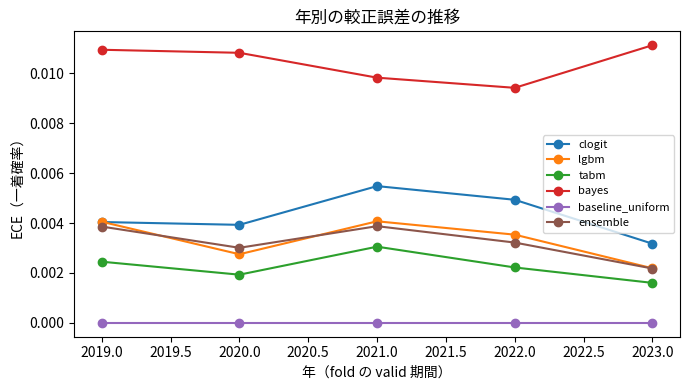

model,baseline_uniform,bayes,clogit,ensemble,lgbm,tabm
year,,,,,,
2019,0.0,0.0109,0.0040,0.0039,0.0041,0.0025
2020,0.0,0.0108,0.0039,0.0030,0.0027,0.0019
2021,0.0,0.0098,0.0055,0.0039,0.0041,0.0031
2022,0.0,0.0094,0.0049,0.0032,0.0035,0.0022
2023,0.0,0.0111,0.0032,0.0022,0.0022,0.0016


In [10]:
fold_years = df.groupby("fold")["race_date"].agg(lambda s: s.dt.year.iloc[0])

fold_rows = []
for fold, sub in df.groupby("fold"):
    for m in ALL_MODELS:
        fold_rows.append(dict(
            fold=fold, year=fold_years[fold], model=m,
            ece_win=expected_calibration_error(sub[m].to_numpy(), sub["is_win"].to_numpy()),
        ))
fold_ece = pd.DataFrame(fold_rows)

fig, ax = plt.subplots(figsize=(7, 4))
for m in ALL_MODELS:
    sub = fold_ece[fold_ece["model"] == m]
    ax.plot(sub["year"], sub["ece_win"], marker="o", label=m)
ax.set_xlabel("年（fold の valid 期間）")
ax.set_ylabel("ECE（一着確率）")
ax.set_title("年別の較正誤差の推移")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("ece_by_year.png", dpi=120)
plt.show()

fold_ece.pivot(index="year", columns="model", values="ece_win").round(4)


## 7. ブロックブートストラップ CI（開催日単位）
ビン単位の Wilson CI は行が独立という前提を置いている。実際は同じレース・同じ開催日の中で
結果が相関するため、レース単位・日付単位で見た方が保守的な区間になる。ここでは複勝側の
較正誤差（|予測 − 実測|の1頭あたり平均、開催日ブロック）を LightGBM とアンサンブルで比較し、
`nar.eval.metrics.block_bootstrap_ci`（このリポジトリの経済指標評価と同じ関数）で信頼区間を出す。


In [11]:
boot_rows = []
for m in HARVILLE_MODELS:
    resid = (df[f"{m}_top3_pred"] - df["top3_flag"]).abs()
    point, lo, hi = block_bootstrap_ci(resid, df["race_date"], n_iter=2000, seed=0)
    boot_rows.append(dict(model=m, mean_abs_error=point, ci_lo=lo, ci_hi=hi))
pd.DataFrame(boot_rows).round(4)


,model,mean_abs_error,ci_lo,ci_hi
0,lgbm,0.3236,0.3227,0.3244
1,ensemble,0.3238,0.3229,0.3247


## 8. 結論と申し送り事項

- **一着確率の較正**: 全体 ECE は §2 のサマリー表のとおり小さい（LightGBM/アンサンブル/TabM
  が 0.2〜0.3%、条件付きロジットが 0.4%、ベイズだけ 1.0% とやや粗い）。§6 の年次推移でも
  5年間を通じて同水準で安定しており、構造変化の兆候はない。
- **複勝（3着以内）確率の較正**: Harville 近似の全体平均は実測3着以内率とほぼ一致するが
  （§2 の `top3` 列と整合）、§4 のビン別に見ると **単調な系統誤差**がある。予測確率
  0.4 付近まではモデルが**過小評価**（例: LightGBM で予測 7.6% → 実測 9.4%、
  予測 20.1% → 実測 23.4%）、予測確率が最も高い最終ビンでは逆に**過大評価**
  （予測 81.7% → 実測 71.5%、10pt 差）に転じる。§5 の BH 補正後も
  76件中54件が有意（`padj<0.05`）で、これは誤差の大きさから見ても偶然のブレではない。
  §3（一着）の ECE ≈0.003 に対し、§4（複勝）の同種の指標は ≈0.03 と1桁大きい。
  Harville の IIA（無関係な選択肢からの独立性）仮定——上位が確定するたびに残りの馬の
  相対力量比が変わらないという単純化——が競馬の実態（例えば逃げ馬は先頭を守れないと
  一気に崩れるなど、着順が進むほど不確実性が増す馬がいる）とズレている可能性が高い。
  **単勝確率をそのまま Harville に通した複勝確率を複勝馬券の期待値計算に使うのは
  危険**で、実務では複勝側に別途較正（例: 温度スケーリングやビン別の実測補正係数）を
  掛けるべき。
- **データの制約**: 本ノートブックはロック区間（2024-02〜現在の OOS）ではなく walk-forward の
  OOF（2019-2023）を使っている。`narops`/`nar` 側で `evaluate-final` が行単位の予測を
  永続化するよう拡張すれば、配布モデルそのものの複勝キャリブレーションをロック区間で
  確認できる（現状は集計指標のみ `artifacts/oos_metrics.json` に残る）。これは
  `docs/MaintenanceRunbook.md` §7 に申し送り事項として記載済み。
